In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

## Helpers

In [6]:

from datetime import datetime
import pytz
def percent_nan_per_col(df, column):
        return (df[column].isnull().sum() / len(df)) * 100


def compare_datetimes(publishedDate, eventDate):
    # Parse first date: "12/2/2022 0:00" (assumed to be local or naive)
    date1 = datetime.strptime(eventDate.strip(), "%m/%d/%Y %H:%M")
    date1 = date1.replace(tzinfo=pytz.UTC)  # Assume UTC; adjust if needed

    # Parse second date: "2020-12-31T18:15:00Z" (ISO 8601 UTC format)
    date2 = datetime.strptime(publishedDate, "%Y-%m-%dT%H:%M:%SZ")
    date2 = date2.replace(tzinfo=pytz.UTC)

    # Calculate time difference
    delta = date1 - date2

    # Return time difference in a friendly format
    return delta.days

#{
#        "days": delta.days,
#        "seconds": delta.total_seconds(),
#        "hours": delta.total_seconds() / 3600,
#    }

# Data

In [2]:
folderPC = "C:/Users/Michael/Desktop/CS-513/Final Project/"
folderLaptop = "C:/Users/Michael/OneDrive - stevens.edu/Desktop/CS-513/Final Project/"
folder = folderPC

In [ ]:
df2 = pd.read_csv(folder + "normalized_labeled_data.csv", na_values=['?'])

# Run thru HighestInjuryLevel and injuries to determine which ones have NA for all
# Remove the ones with NA for all
# Try to run model
# If model doesn't run, take a deeper look
# If model runs, evaluate!



### Load & Transform

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np

from datetime import timezone
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(folder + "normalized_labeled_data.csv", na_values=['?'])

cols = ['FatalInjuryCount','SeriousInjuryCount','MinorInjuryCount','OnboardInjuryCount']

indexes = []
non_na = 0

for index, row in df.iterrows():
    obj = {}
    counts = 0
    for col in cols:
        obj[col] = row[col]
        if row[col] >= 0.0:
            non_na += 1
        else:
            counts += 1
    if counts >= 4:
        indexes.append(index)

print("Non-NA: ", non_na)
df = df.drop(indexes)

data = []
for index, row in df.iterrows():
    x = row['OriginalPublishedDate']
    if (type(x) == float):
        iso_utc_now = datetime.now(timezone.utc).strftime("%m/%d/%Y %H:%M")
        timeDelta = compare_datetimes(row['EventDate'], iso_utc_now)
        data.append(timeDelta)
    else: 
        timeDelta = compare_datetimes(row['EventDate'], row['OriginalPublishedDate'])
        data.append(timeDelta)

arr = np.array(data)

scaler = MinMaxScaler()
df['DaysUntilPublished'] = scaler.fit_transform(arr.reshape(-1, 1))

bool_cols = ["AmateurBuilt","HasSafetyRec"]
simple_cols = ["EventType","Mode","AirCraftCategory","EngineType","PurposeOfFlight","FAR","AirCraftDamage","WeatherCondition","BroadPhaseofFlight","ReportStatus","MostRecentReportType"]
sparse_cols = ["Model","Make","AirportID"]

for col in simple_cols:
    encoder = LabelEncoder()
    encoded_data = np.array(encoder.fit_transform(df[col]))
    scaler = MinMaxScaler()
    encoded_data = np.array(scaler.fit_transform(encoded_data.reshape(-1, 1)))
    df[col] = encoded_data

for col in sparse_cols:
    encoder = LabelEncoder()
    encoded_data = np.array(encoder.fit_transform(df[col]))
    scaler = MinMaxScaler()
    encoded_data = np.array(scaler.fit_transform(encoded_data.reshape(-1, 1)))
    df[col] = encoded_data

scaler = MinMaxScaler()
df['NumberOfEngines'] = df['NumberOfEngines'].replace('?', np.nan).astype(float)
df['NumberOfEngines'] = scaler.fit_transform(df[["NumberOfEngines"]])

fatalYN = [] # 1 is Fatal, 0 is non Fatal 

for index, row in df.iterrows():
    x = 0
    if row['HighestInjuryLevel'] == 'Fatal':
        fatalYN.append(True)
        continue
    elif row['HighestInjuryLevel'] == ('Serious' or 'Minor'):
        fatalYN.append(False)
        continue
    if type(row['FatalInjuryCount']) == float:
        if row['FatalInjuryCount'] > 0.0:
            fatalYN.append(True)
        else:
            fatalYN.append(False)
    else:
        fatalYN.append('?')
    

df['FatalYN'] = fatalYN
print(Counter(df['FatalYN']))


Non-NA:  31152
Counter({False: 6232, True: 1575})


In [9]:
df = df.drop(columns=['index', 'DaysUntilPublished', 'HighestInjuryLevel', 'FatalInjuryCount','SeriousInjuryCount','MinorInjuryCount','OnboardInjuryCount', 'OriginalPublishedDate', 'EventDate'])
print(df.head())
print(len(df))
df = df.dropna()
print(len(df))

   EventType  HasSafetyRec  Mode      Make     Model  AirCraftCategory  \
0        0.5         False   0.0  0.184030  0.136239          0.090909   
1        0.0         False   0.0  0.673764  0.695413          0.090909   
2        0.0         False   0.0  0.184030  0.034404          0.090909   
3        0.0         False   0.0  0.114829  0.055505          0.090909   
5        0.0         False   0.0  0.611407  0.612844          0.090909   

   AirportID  AmateurBuilt  NumberOfEngines  EngineType  PurposeOfFlight  FAR  \
0   0.749467         False            0.250         0.6         0.681818  0.0   
1   0.788557         False            0.125         0.5         0.681818  0.0   
2   0.138237         False            0.125         0.5         0.590909  0.0   
3   0.518124         False              NaN         0.0         0.000000  0.4   
5   0.708955         False            0.125         0.5         0.681818  0.0   

   AirCraftDamage  WeatherCondition  BroadPhaseofFlight  ReportStatu

In [10]:
X = df.drop(columns=['FatalYN', "ReportStatus", "EngineType", "HasSafetyRec"])
y = df['FatalYN']

In [11]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

undersample = RandomUnderSampler(random_state=42)
X_st, y_st = undersample.fit_resample(X, y)
print(len(X_st), len(X), Counter(y_st))
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_st, y_st, test_size=0.3, random_state=42)

model = make_pipeline(KNNImputer(n_neighbors=5), GaussianNB())
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")
print(f"\n Confusion Matrix:") 
print(confusion_matrix(y_test, preds))
print(f"\n Classification Report:")
print(classification_report(y_test, preds))

2314 6541 Counter({False: 1157, True: 1157})
Accuracy: 0.78

 Confusion Matrix:
[[264  90]
 [ 63 278]]

 Classification Report:
              precision    recall  f1-score   support

       False       0.81      0.75      0.78       354
        True       0.76      0.82      0.78       341

    accuracy                           0.78       695
   macro avg       0.78      0.78      0.78       695
weighted avg       0.78      0.78      0.78       695



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd




model = RandomForestClassifier(n_estimators=111, criterion='entropy', max_depth=5, max_leaf_nodes=17)
#model = DecisionTreeClassifier(criterion='gini', max_depth=10, max_leaf_nodes=20)


smote = SMOTETomek(random_state=42)
X_st, y_st = smote.fit_resample(X, y)
print(Counter(y_st))


# 60 - 20 - 20 split
                                                                 # 20% 
XX_train, XX_test, yy_train, yy_test = train_test_split(X_st, y_st, test_size=0.2, random_state=3) # validation set

undersample2 = RandomUnderSampler(random_state=32)
XX_us, yy_us = undersample2.fit_resample(XX_train, yy_train)


smote2 = SMOTETomek(random_state=57)
XX_st, yy_st = smote2.fit_resample(XX_train, yy_train)

print(Counter(yy_us))
                                                                        # 25% * 80% = 20%
X_train, X_test, y_train, y_test = train_test_split(XX_us, yy_us, test_size=0.25, random_state=77) # training set

print("Training")

model.fit(X_train,y_train)
target_pred = model.predict(X_test)
print(f"\n Accuracy: {accuracy_score(y_test,target_pred)}  ")
print(f"\n Confusion Matrix:") 
print(confusion_matrix(y_test,target_pred))
print(f"\n Classification Report:")
print(classification_report(y_test,target_pred))

print("Validation")

#model.fit(XX_train,yy_train)
target_pred = model.predict(XX_test)
print(f"\n Accuracy: {accuracy_score(yy_test,target_pred)}  ")
print(f"\n Confusion Matrix:") 
print(confusion_matrix(yy_test,target_pred))
print(f"\n Classification Report:")
print(classification_report(yy_test,target_pred))
print("\n Feature Importance:")
print(model.feature_importances_)
print("\n Permutation Performance: ")
result = permutation_importance(model, X, y)
for feature, mean, std in zip(X.columns, result.importances_mean, result.importances_std):
    print(f"{feature}: {mean:.4f} +/- {std:.4f}")


#plt.figure(figsize=(50,30), dpi=250)
#plot_tree(model,fontsize=20,filled=True,feature_names=X.columns)

Counter({False: 5256, True: 5256})
Counter({False: 4203, True: 4203})
Training

 Accuracy: 0.8258801141769743  

 Confusion Matrix:
[[954 131]
 [235 782]]

 Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.88      0.84      1085
        True       0.86      0.77      0.81      1017

    accuracy                           0.83      2102
   macro avg       0.83      0.82      0.82      2102
weighted avg       0.83      0.83      0.83      2102

Validation

 Accuracy: 0.823585354255825  

 Confusion Matrix:
[[932 121]
 [250 800]]

 Classification Report:
              precision    recall  f1-score   support

       False       0.79      0.89      0.83      1053
        True       0.87      0.76      0.81      1050

    accuracy                           0.82      2103
   macro avg       0.83      0.82      0.82      2103
weighted avg       0.83      0.82      0.82      2103


 Feature Importance:
[0.02916476 0.         0.0131774 

In [164]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 250),
    'max_depth': randint(3, 30),
    'max_leaf_nodes': randint(10, 100)
}

dt = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=dt, param_distributions=param_dist, 
                                   n_iter=50, cv=5, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)

Best parameters: {'max_depth': 18, 'max_leaf_nodes': 32, 'n_estimators': 111}


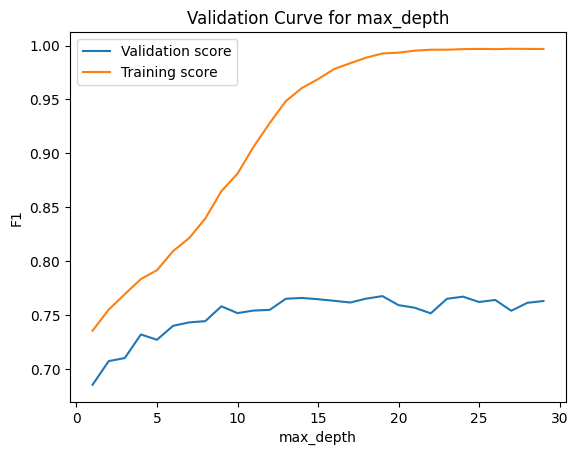

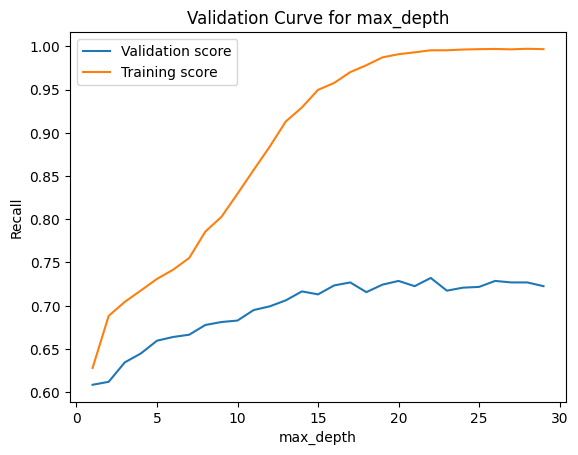

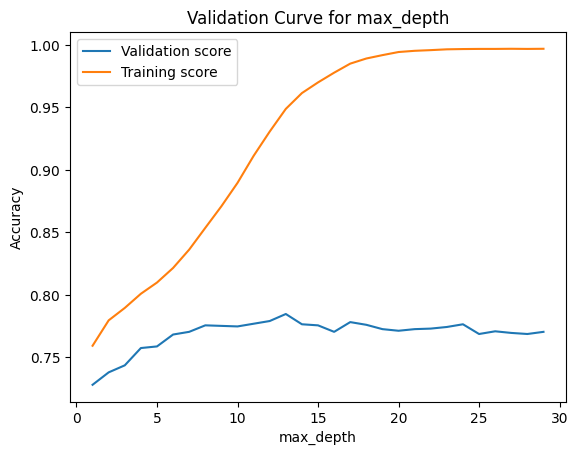

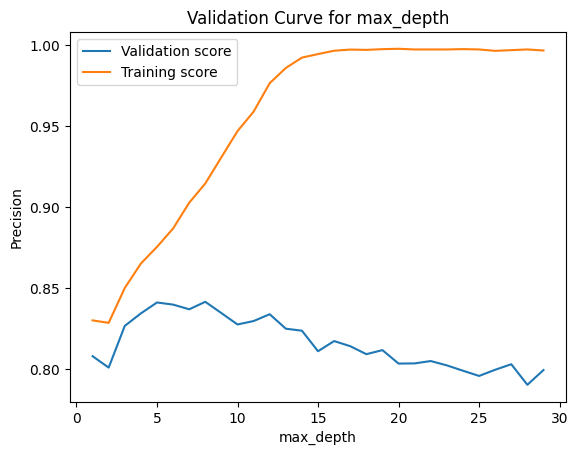

In [15]:
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

undersample = RandomUnderSampler(random_state=42)
X_st, y_st = undersample.fit_resample(X, y)

param_name = "max_depth"
param_range = range(1, 30)
train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100),
    X_st, y_st,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring="f1"
)

train_scores2, test_scores2 = validation_curve(
    RandomForestClassifier(n_estimators=100),
    X_st, y_st,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring="recall"
)

train_scores3, test_scores3 = validation_curve(
    RandomForestClassifier(n_estimators=100),
    X_st, y_st,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

train_scores4, test_scores4 = validation_curve(
    RandomForestClassifier(n_estimators=100),
    X_st, y_st,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring="precision"
)

plt.plot(param_range, test_scores.mean(axis=1), label="Validation score")
plt.plot(param_range, train_scores.mean(axis=1), label="Training score")
plt.xlabel(param_name)
plt.ylabel("F1")
plt.legend()
plt.title(f"Validation Curve for {param_name}")
plt.show()

plt.plot(param_range, test_scores2.mean(axis=1), label="Validation score")
plt.plot(param_range, train_scores2.mean(axis=1), label="Training score")
plt.xlabel(param_name)
plt.ylabel("Recall")
plt.legend()
plt.title(f"Validation Curve for {param_name}")
plt.show()

plt.plot(param_range, test_scores3.mean(axis=1), label="Validation score")
plt.plot(param_range, train_scores3.mean(axis=1), label="Training score")
plt.xlabel(param_name)
plt.ylabel("Accuracy")
plt.legend()
plt.title(f"Validation Curve for {param_name}")
plt.show()

plt.plot(param_range, test_scores4.mean(axis=1), label="Validation score")
plt.plot(param_range, train_scores4.mean(axis=1), label="Training score")
plt.xlabel(param_name)
plt.ylabel("Precision")
plt.legend()
plt.title(f"Validation Curve for {param_name}")
plt.show()

# Further Exploration

### Crashes per country (Useless since 90% of flight data are US-based since NTSB is a US-based organization)

{'Other Foreign': 724, 'Texas': 568, 'California': 541, 'Florida': 481, 'Alaska': 425, 'Arizona': 231, 'Georgia': 203, 'Colorado': 202, 'Washington': 174, 'North Carolina': 173, 'Idaho': 156, 'Oregon': 140, 'Utah': 139, 'New York': 138, 'Illinois': 129, 'Tennessee': 129, 'Minnesota': 123, 'Ohio': 119, 'Pennsylvania': 117, 'Michigan': 113, 'Virginia': 112, 'Wisconsin': 112, 'Louisiana': 108, 'Missouri': 107, 'Nevada': 106, 'Oklahoma': 102, 'Arkansas': 100, 'Indiana': 92, 'South Carolina': 92, 'Montana': 87, 'Alabama': 84, 'New Mexico': 83, 'Kansas': 77, 'New Jersey': 66, 'Iowa': 66, 'Nebraska': 62, 'Kentucky': 60, 'Maryland': 54, 'Wyoming': 51, 'Mississippi': 47, 'Hawaii': 46, 'Massachusetts': 44, 'North Dakota': 33, 'New Hampshire': 31, 'Maine': 29, 'South Dakota': 29, 'Connecticut': 28, 'West Virginia': 27, 'Puerto Rico': 13, 'Vermont': 12, 'Atlantic Ocean': 9, 'Delaware': 8, 'Rhode Island': 7, 'Pacific Ocean': 4, 'Caribbean Sea': 4, 'Gulf of America': 3, 'District of Columbia': 1}


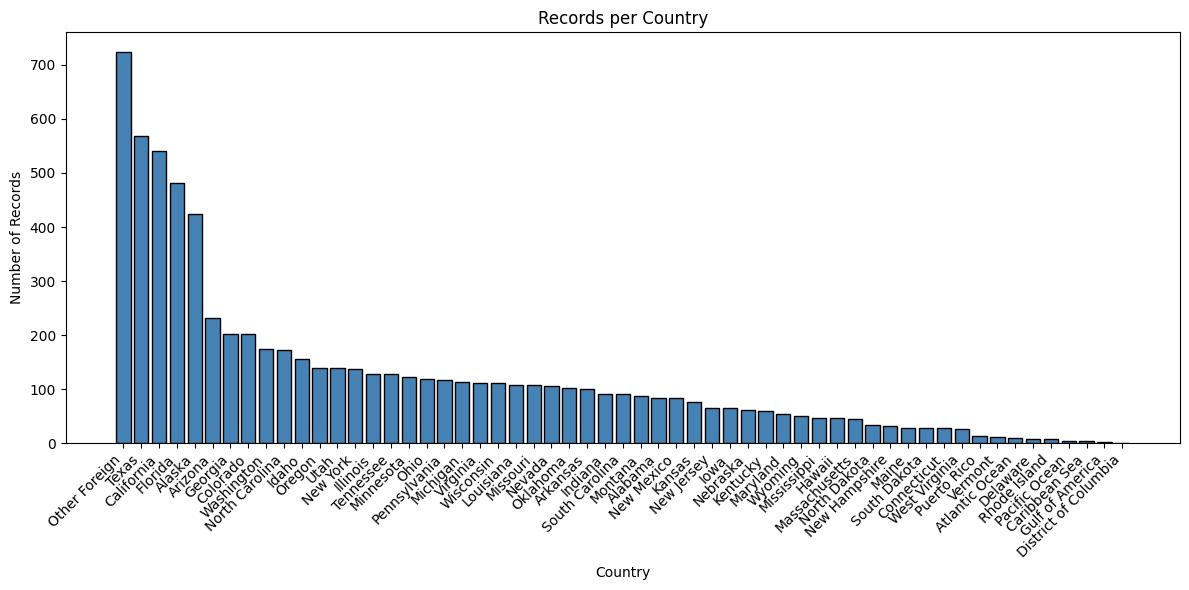

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

def is_float(x):
    return type(x) != float

def plot_country_distribution(records):
    # Assume each record is a dict with a 'country' key
    country_counts = Counter(filter(is_float, records))

    # Sort by frequency
    sorted_counts = dict(sorted(country_counts.items(), key=lambda item: item[1], reverse=True))
    print(sorted_counts)
    
    
    # Plot
    plt.figure(figsize=(12, 6))
    # Use only top 10 countries behind US
    plt.bar(list(sorted_counts.keys()), list(sorted_counts.values()), color='steelblue', edgecolor='black')
    plt.xlabel('Country')
    plt.ylabel('Number of Records')
    plt.title('Records per Country')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_country_distribution(df2['State'])

In [7]:
from datetime import datetime
import pytz

def compare_datetimes(publishedDate, eventDate):
    # Parse first date: "12/2/2022 0:00" (assumed to be local or naive)
    date1 = datetime.strptime(eventDate.strip(), "%m/%d/%Y %H:%M")
    date1 = date1.replace(tzinfo=pytz.UTC)  # Assume UTC; adjust if needed

    # Parse second date: "2020-12-31T18:15:00Z" (ISO 8601 UTC format)
    date2 = datetime.strptime(publishedDate, "%Y-%m-%dT%H:%M:%SZ")
    date2 = date2.replace(tzinfo=pytz.UTC)

    # Calculate time difference
    delta = date1 - date2

    # Return time difference in a friendly format
    return delta.days

#{
#        "days": delta.days,
#        "seconds": delta.total_seconds(),
#        "hours": delta.total_seconds() / 3600,
#    }


### Find distribution over months of year

8411


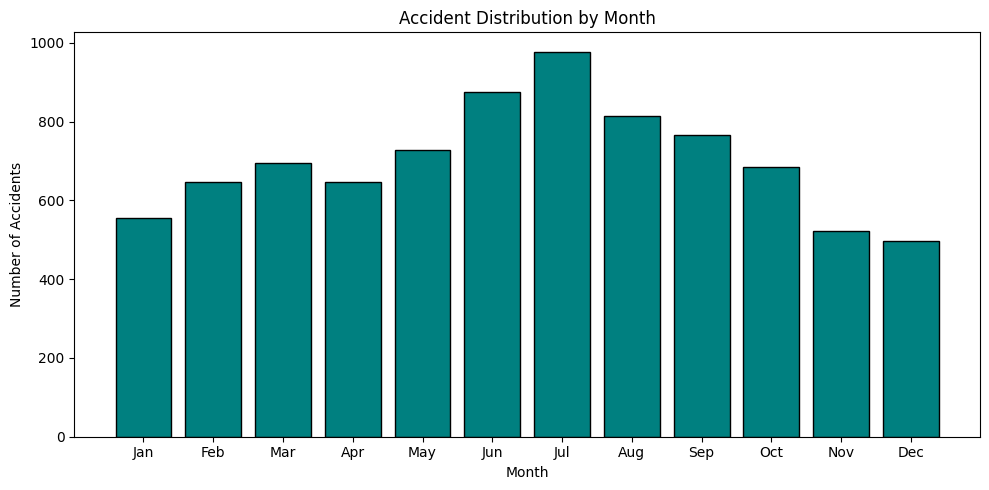

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

def plot_monthly_distribution(dates):
    # Parse dates and extract month numbers (1–12)
    months = [datetime.strptime(date.strip(), "%Y-%m-%dT%H:%M:%SZ").month for date in dates]
    print(len(months))
    # Count occurrences per month
    counts = Counter(months)

    # Ensure all months are represented, even with 0 count
    all_months = list(range(1, 13))
    frequencies = [counts.get(m, 0) for m in all_months]

    # Month labels
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(month_labels, frequencies, color='teal', edgecolor='black')
    plt.title('Accident Distribution by Month')
    plt.xlabel('Month')
    plt.ylabel('Number of Accidents')
    plt.tight_layout()
    plt.show()

# Usage
plot_monthly_distribution(df2['EventDate'])

### Find days between event date and publish date of report

C:\Users\michael\AppData\Local\Temp\ipykernel_17068\1229376141.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  iso_utc_now = datetime.utcnow().replace(tzinfo=timezone.utc).strftime("%m/%d/%Y %H:%M")


[700, 262, 291, 1580, 1580, 232, 673, 197, 1581, 1581, 198, 233, 1582, 707, 1583, 567, 560, 234, 1583, 764, 766, 200, 676, 267, 201, 1585, 268, 1586, 564, 378, 1589, 205, 205, 1589, 241, 617, 567, 683, 667, 242, 569, 774, 669, 209, 670, 606, 782, 685, 636, 573, 247, 282, 1598, 570, 668, 669, 669, 786, 1600, 251, 670, 251, 781, 285, 789, 257, 218, 575, 575, 254, 588, 512, 675, 256, 577, 257, 1606, 619, 1607, 1608, 679, 1609, 320, 796, 679, 1609, 582, 261, 1610, 681, 263, 263, 295, 264, 295, 264, 1613, 265, 1615, 991, 299, 686, 268, 679, 1617, 680, 786, 1619, 281, 301, 661, 593, 284, 277, 594, 599, 237, 238, 238, 1623, 1624, 275, 686, 240, 695, 666, 1626, 277, 611, 1627, 242, 305, 242, 535, 613, 206, 306, 306, 280, 601, 1629, 797, 307, 602, 638, 768, 603, 1631, 247, 287, 1633, 295, 288, 681, 284, 248, 1634, 611, 289, 312, 606, 607, 607, 1056, 286, 815, 1635, 250, 607, 297, 818, 608, 251, 1636, 649, 1638, 868, 253, 665, 650, 254, 301, 703, 255, 765, 1641, 866, 1642, 614, 1642, 294, 1643, 

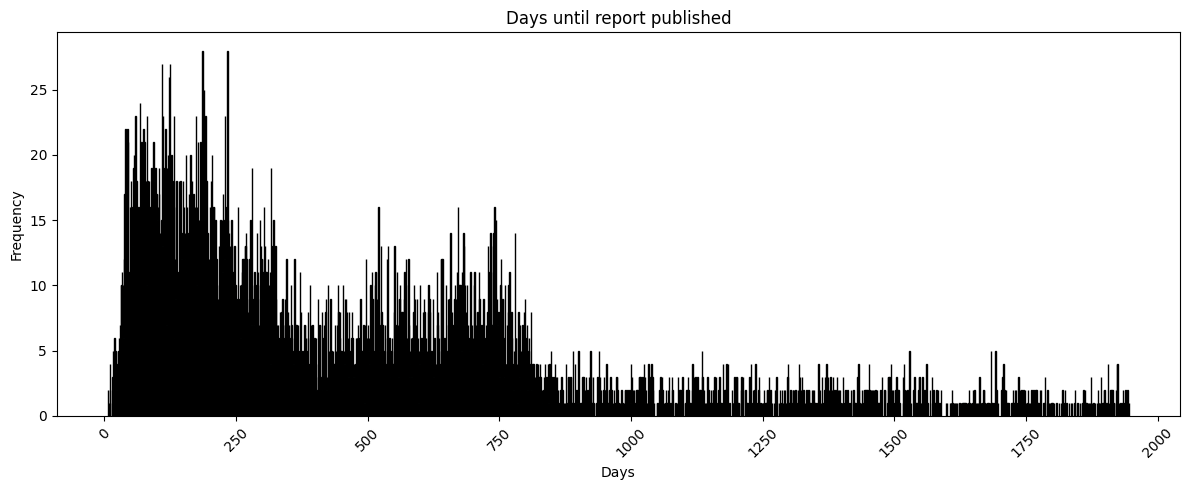

0.0


In [9]:
from datetime import timezone
from collections import Counter
missing = 0
data = []
for index, log in df2.iterrows():
    x = log['OriginalPublishedDate']
    if (type(x) == float):
        iso_utc_now = datetime.utcnow().replace(tzinfo=timezone.utc).strftime("%m/%d/%Y %H:%M")
        timeDelta = compare_datetimes(log['EventDate'], iso_utc_now)
        data.append(timeDelta)
    else: 
        timeDelta = compare_datetimes(log['EventDate'], log['OriginalPublishedDate'])
        data.append(timeDelta)

print(data)

# Count the frequency of each number
freq = Counter(data)
# Separate keys and values
labels = list(freq.keys())
counts = list(freq.values())
# Create a bar plot
plt.figure(figsize=(12, 5))
plt.bar(labels, counts, color='skyblue', edgecolor='black')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.title('Days until report published')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(missing / len(df2))
    

In [25]:
dataF = pd.DataFrame(data)
print(dataF.describe())

                 0
count  5356.000000
mean    345.072069
std     247.023188
min      21.000000
25%     134.750000
50%     258.000000
75%     560.000000
max    1414.000000


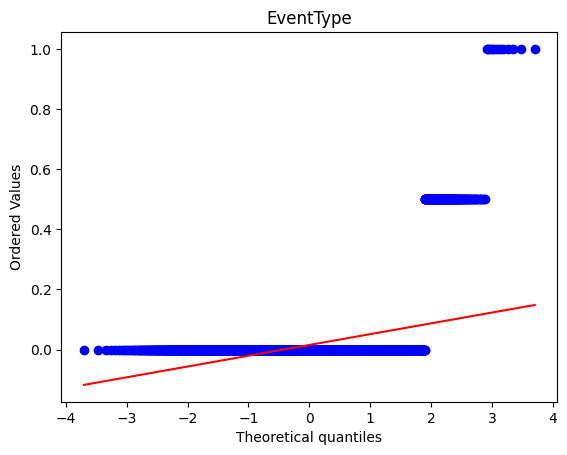

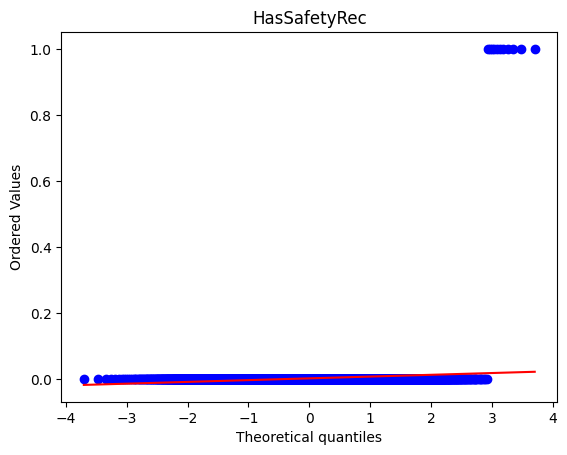

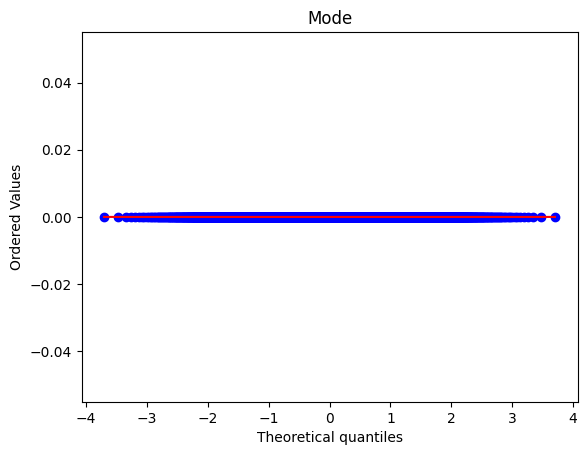

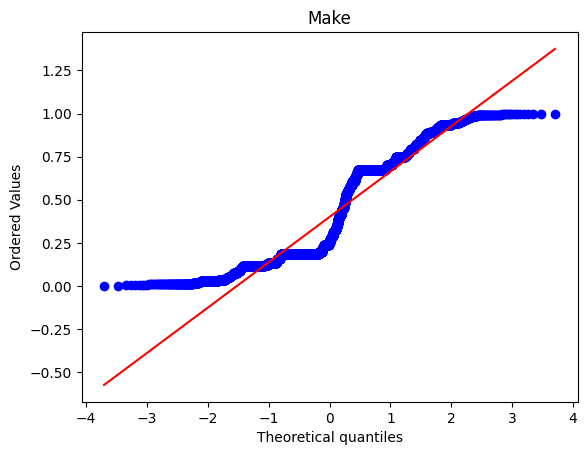

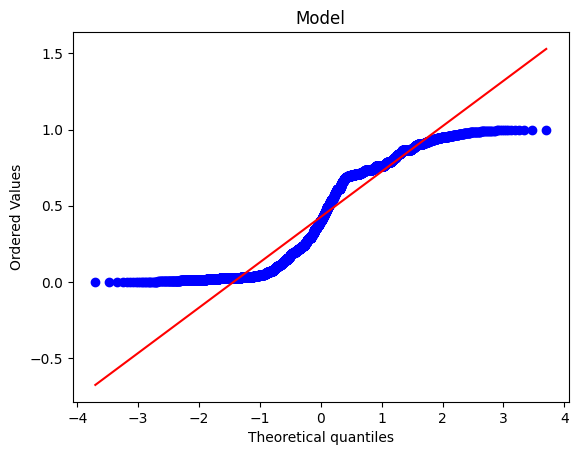

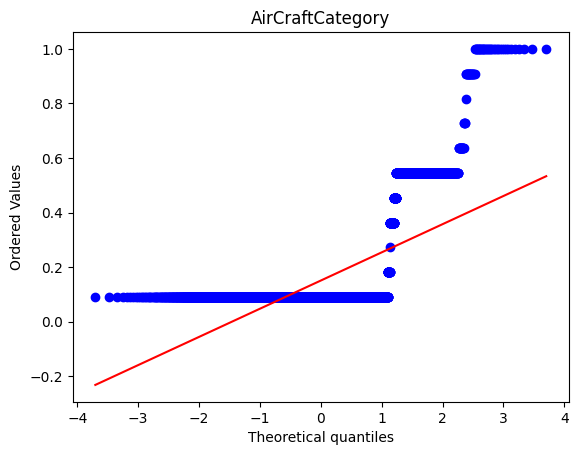

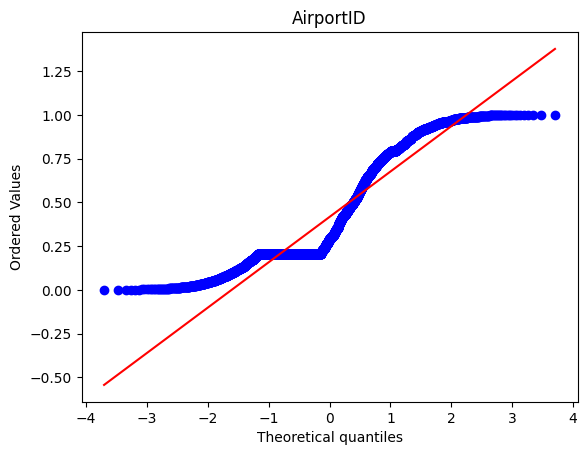

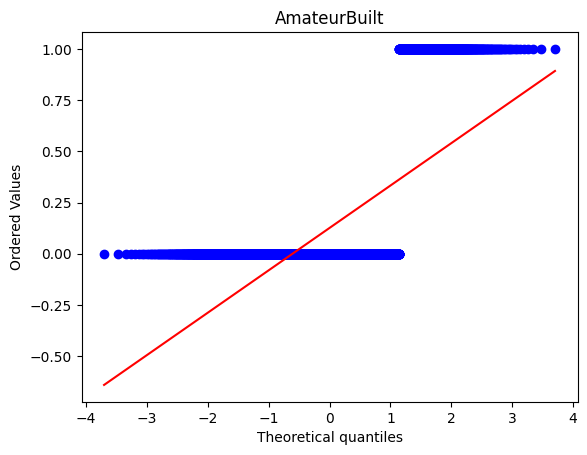

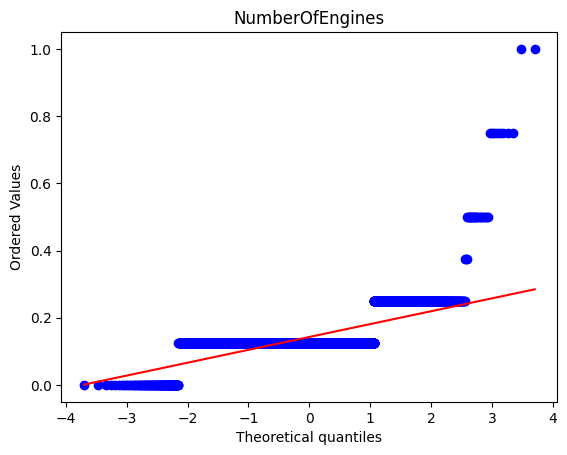

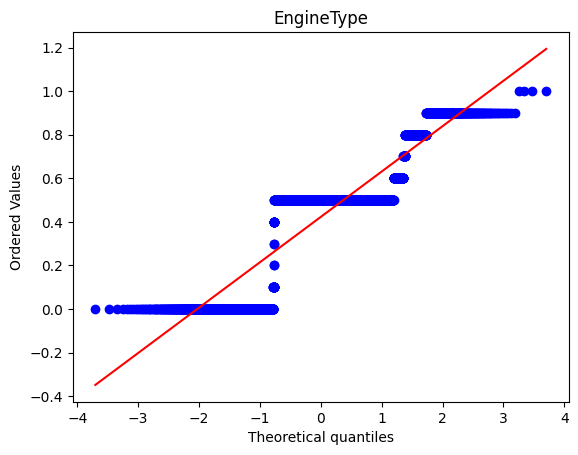

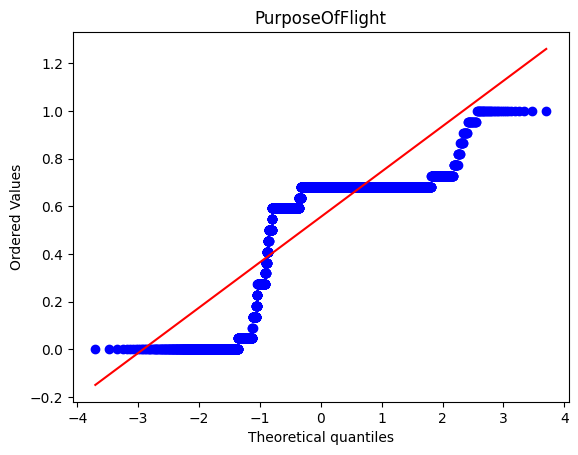

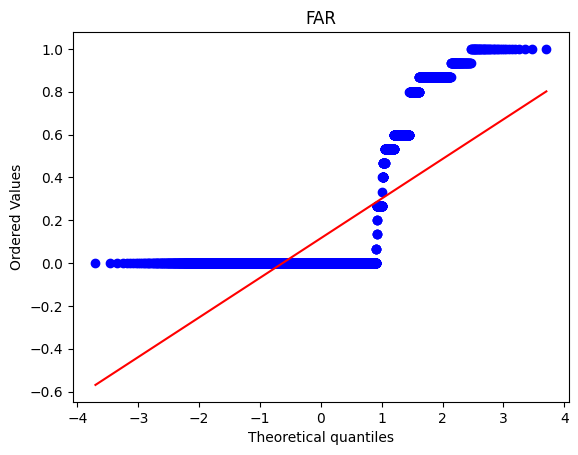

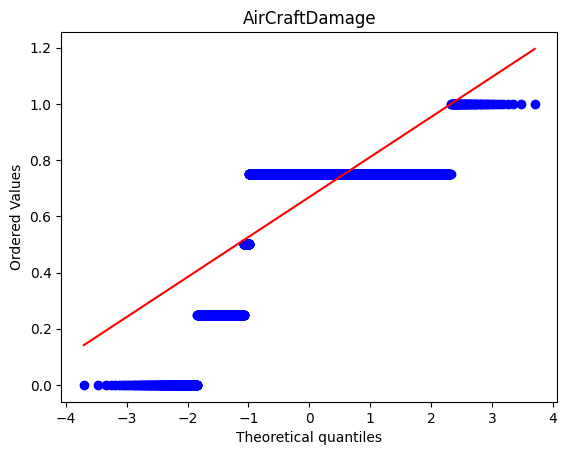

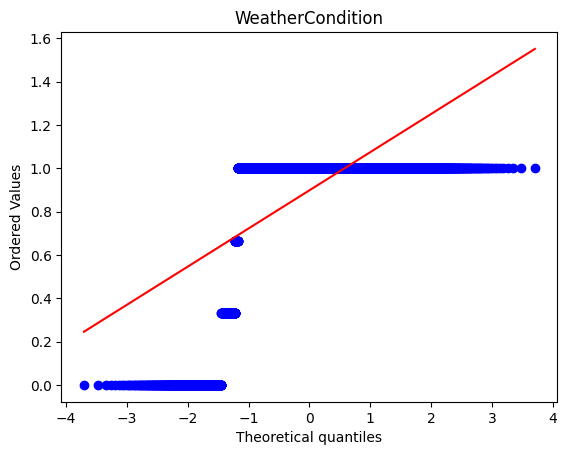

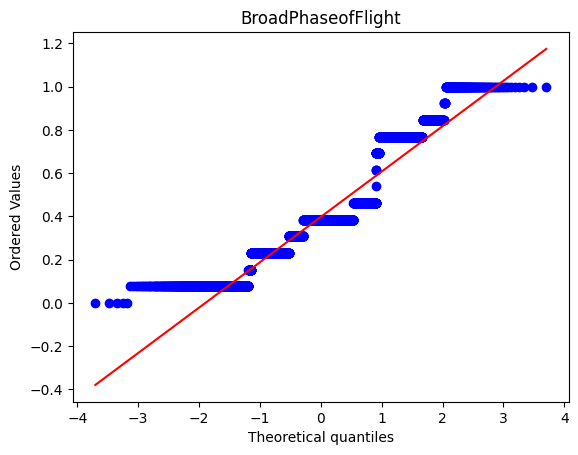

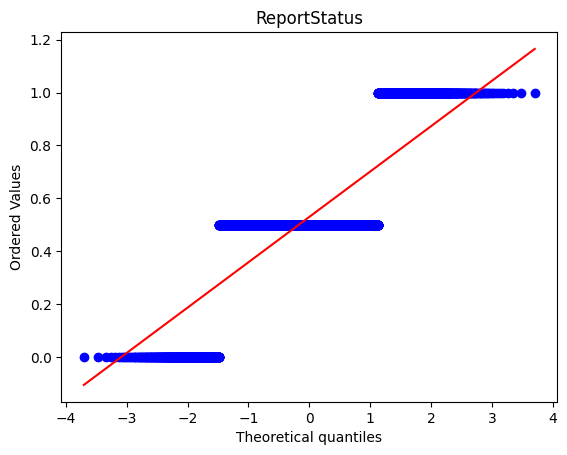

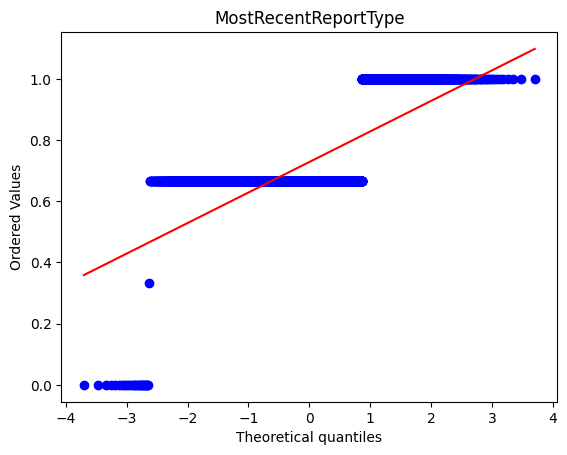

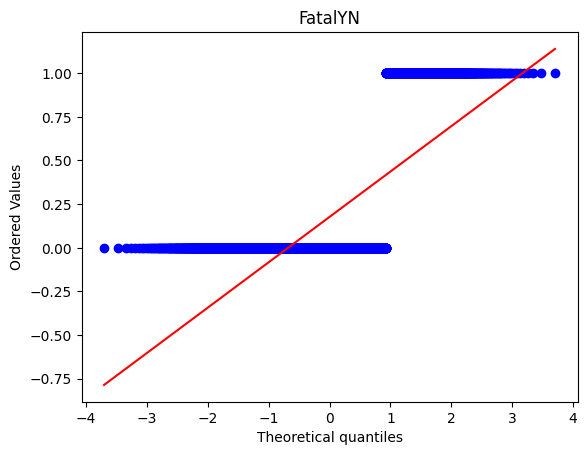

In [189]:
import matplotlib.pyplot as plt   
import scipy.stats as stats
import pylab 


for col in df.columns:
    plt=stats.probplot(df[col], dist="norm", plot=pylab)
    pylab.title(col) 
    pylab.show()